# Edge Detection and Contours

Edges occur where **intensity changes rapidly** (large gradient). This notebook covers gradient-based detectors and **contour** extraction.

**Image sources:** `skimage.data.camera`, ECE533 `peppers` .

---

## 1. Gradients and Sobel

The **Sobel operator** approximates partial derivatives $G_x$, $G_y$ using 3×3 kernels:

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad
G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

**Gradient magnitude:** $|G| = \sqrt{G_x^2 + G_y^2}$

**What Sobel does:** highlights edges; thicker than Canny; sensitive to noise.

---

## 2. Scharr

Same idea as Sobel but **better rotation symmetry** (optimized 3×3 coefficients). Use `cv2.Scharr` when you need more accurate gradients at 3×3 size.

---

## 3. Laplacian

Second derivative — responds to **rapid change in the gradient**. Zero-crossings mark edges. Very noise-sensitive; often combined with Gaussian pre-blur (**LoG**).

---

## 4. Canny (multi-stage)

1. Gaussian smooth  
2. Sobel gradients  
3. Non-maximum suppression (thin edges)  
4. **Hysteresis** thresholding (weak edges kept only if connected to strong)

| Parameter | Role |
|-----------|------|
| `threshold1` | low hysteresis bound |
| `threshold2` | high hysteresis bound |
| `apertureSize` | Sobel kernel size (3, 5, or 7) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from urllib.request import urlretrieve
import skimage.data as skid

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
IMAGES_CACHE = NOTEBOOK_DIR.parent / "Images"
IMAGES_CACHE.mkdir(exist_ok=True)

ECE533_URLS = {
    "peppers": "https://homepages.cae.wisc.edu/~ece533/images/peppers.png",
    "boat": "https://homepages.cae.wisc.edu/~ece533/images/boat.png",
    "baboon": "https://homepages.cae.wisc.edu/~ece533/images/baboon.png",
}

SKIMAGE_FALLBACK = {
    "peppers": skid.astronaut,
    "boat": skid.camera,
    "baboon": skid.chelsea,
}


def load_sample_image(name):
    """Load from skimage.data or download Wisconsin ECE533 image (cached locally)."""
    skimg_map = {
        "camera": skid.camera,
        "coins": skid.coins,
        "astronaut": skid.astronaut,
        "coffee": skid.coffee,
        "chelsea": skid.chelsea,
        "page": skid.page,
    }
    if name in skimg_map:
        img = skimg_map[name]()
        if img.ndim == 2:
            return img.astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cache_path = IMAGES_CACHE / f"{name}.png"
    if cache_path.exists():
        img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
        if img is not None:
            return img

    url = ECE533_URLS.get(name)
    if url:
        try:
            print(f"Downloading {name} from ECE533 ...")
            urlretrieve(url, cache_path)
            img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
            if img is not None:
                return img
        except Exception as exc:
            print(f"Download failed ({exc}); using skimage fallback.")

    fallback = SKIMAGE_FALLBACK.get(name, skid.camera)
    img = fallback()
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)


def to_rgb(bgr):
    if bgr.ndim == 2:
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, img_bgr, title=""):
    ax.imshow(to_rgb(img_bgr))
    ax.set_title(title)
    ax.axis("off")


def side_by_side(images, titles, rgb_flags=None, cols=4):
    """Plot a row/grid of images. images: list of arrays; rgb_flags: True for BGR color."""
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, (img, title) in enumerate(zip(images, titles)):
        is_rgb = rgb_flags[i] if rgb_flags else (img.ndim == 3)
        if is_rgb:
            show_rgb(axes[i], img, title)
        else:
            show_gray(axes[i], img, title)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper(gray, amount=0.05):
    """Inject salt-and-pepper noise into a uint8 grayscale image."""
    out = gray.copy()
    n = int(amount * gray.size)
    rng = np.random.default_rng(42)
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 255
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 0
    return out


Download failed (HTTP Error 403: Forbidden); using skimage fallback.


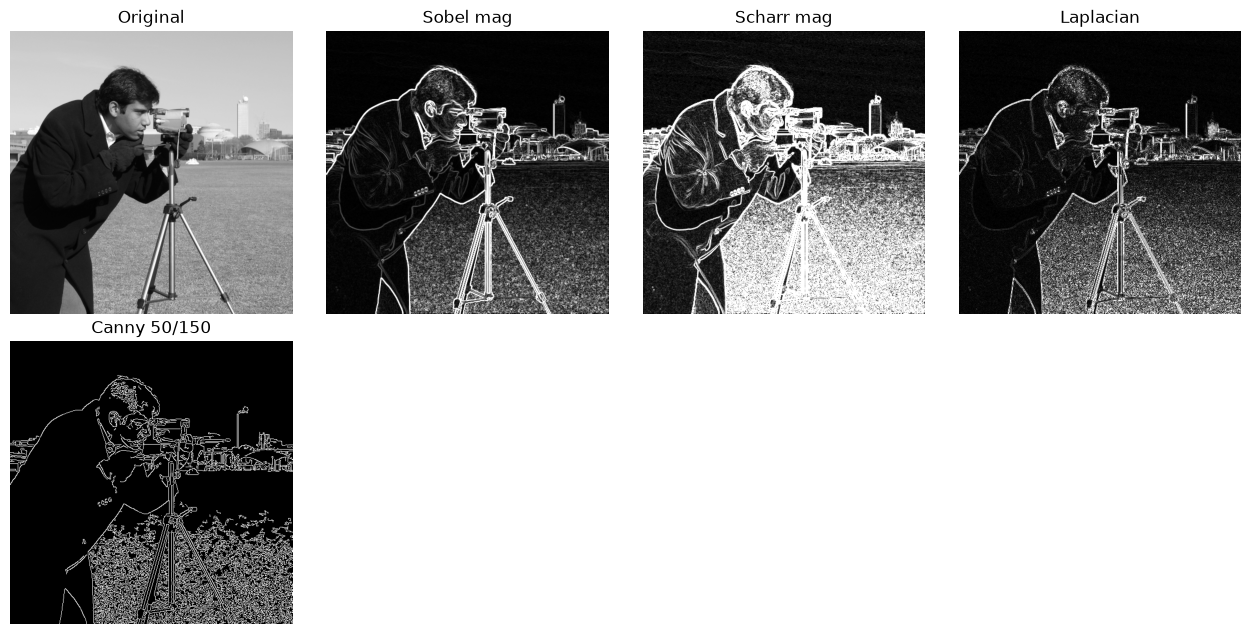

In [2]:
camera = load_sample_image("camera")
peppers = load_sample_image("peppers")
if peppers.ndim == 3:
    peppers_gray = cv2.cvtColor(peppers, cv2.COLOR_BGR2GRAY)
else:
    peppers_gray = peppers

# Sobel
gx = cv2.Sobel(camera, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(camera, cv2.CV_64F, 0, 1, ksize=3)
mag = cv2.magnitude(gx, gy)
mag_u8 = cv2.convertScaleAbs(mag)

# Scharr
sx = cv2.Scharr(camera, cv2.CV_64F, 1, 0)
sy = cv2.Scharr(camera, cv2.CV_64F, 0, 1)
scharr_mag = cv2.convertScaleAbs(cv2.magnitude(sx, sy))

# Laplacian
lap = cv2.Laplacian(camera, cv2.CV_64F, ksize=3)
lap_u8 = cv2.convertScaleAbs(lap)

# Canny
canny = cv2.Canny(camera, 50, 150)

side_by_side(
    [camera, mag_u8, scharr_mag, lap_u8, canny],
    ["Original", "Sobel mag", "Scharr mag", "Laplacian", "Canny 50/150"],
)


## 5. Canny threshold tuning

Low `threshold1` / `threshold2` → more edges (including noise). High values → fewer, stronger edges only.


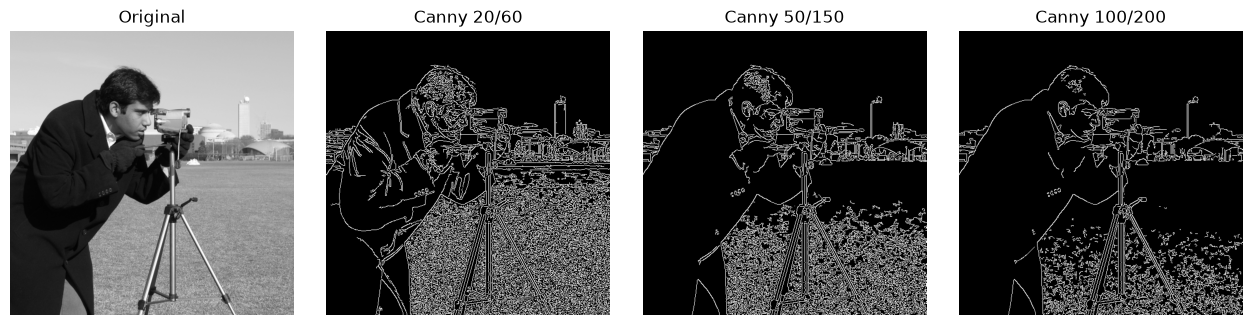

In [3]:
canny_lo = cv2.Canny(camera, 20, 60)
canny_hi = cv2.Canny(camera, 100, 200)
side_by_side([camera, canny_lo, canny, canny_hi],
             ["Original", "Canny 20/60", "Canny 50/150", "Canny 100/200"])


## 6. Contours

**Contour:** curve joining continuous points along a **boundary** of the same intensity (usually white regions in a binary image).

`cv2.findContours(image, mode, method)` — input should be **binary** (threshold or Canny).

### Retrieval modes

| Mode | Returns |
|------|---------|
| `RETR_EXTERNAL` | Outer boundaries only (ignore holes inside objects) |
| `RETR_LIST` | All contours, flat list, no parent/child info |
| `RETR_TREE` | All contours + **hierarchy** (which contour is inside another) |

`CHAIN_APPROX_SIMPLE` compresses straight segments (fewer points than `CHAIN_APPROX_NONE`).

### Shape descriptors (largest contour)

| Function | What it gives |
|----------|----------------|
| `cv2.contourArea` | Area in pixels² |
| `cv2.arcLength` | Perimeter length |
| `cv2.boundingRect` | Axis-aligned rectangle (x, y, w, h) |
| `cv2.minAreaRect` | Rotated minimum-area rectangle |
| `cv2.minEnclosingCircle` | Smallest circle containing the contour |
| `cv2.convexHull` | Convex outer shell |
| `cv2.approxPolyDP` | Polygon with fewer vertices (epsilon controls detail) |
| `cv2.moments` | Centroid, area, orientation statistics |


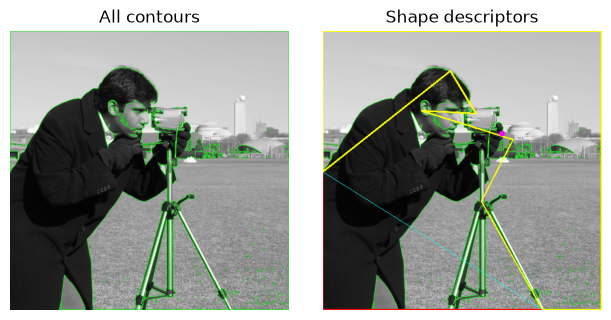

Area: 138340  Perimeter: 3683.9  Centroid: (329, 188)
Blue=bbox  Red=minAreaRect  Orange=minEnclosingCircle  Yellow=hull  Cyan=approx  Magenta=centroid


In [4]:
# --- Example A: single object — shape descriptors on camera ---
_, thresh = cv2.threshold(camera, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

canvas = cv2.cvtColor(camera, cv2.COLOR_GRAY2BGR)
cv2.drawContours(canvas, contours, -1, (0, 255, 0), 1)

cnt = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(cnt)
rect = cv2.minAreaRect(cnt)
box = cv2.boxPoints(rect).astype(int)
hull = cv2.convexHull(cnt)
epsilon = 0.02 * cv2.arcLength(cnt, True)
approx = cv2.approxPolyDP(cnt, epsilon, True)
(center, radius) = cv2.minEnclosingCircle(cnt)
M = cv2.moments(cnt)
cx = int(M["m10"] / M["m00"]) if M["m00"] else 0
cy = int(M["m01"] / M["m00"]) if M["m00"] else 0

annot = canvas.copy()
cv2.rectangle(annot, (x, y), (x + w, y + h), (255, 0, 0), 2)
cv2.drawContours(annot, [box], 0, (0, 0, 255), 2)
cv2.circle(annot, (int(center[0]), int(center[1])), int(radius), (255, 128, 0), 2)
cv2.drawContours(annot, [hull], -1, (255, 255, 0), 1)
cv2.drawContours(annot, [approx], -1, (0, 255, 255), 2)
cv2.circle(annot, (cx, cy), 5, (255, 0, 255), -1)

side_by_side([canvas, annot], ["All contours", "Shape descriptors"], rgb_flags=[True, True])
print(f"Area: {cv2.contourArea(cnt):.0f}  Perimeter: {cv2.arcLength(cnt, True):.1f}  Centroid: ({cx}, {cy})")
print("Blue=bbox  Red=minAreaRect  Orange=minEnclosingCircle  Yellow=hull  Cyan=approx  Magenta=centroid")


### 6.1 Additional examples

**B — Canny vs Otsu:** thin edge map vs filled regions give different contours.

**C — `RETR_*` modes on coins:** same binary image, different contour counts (holes vs no holes).

**D — `approxPolyDP`:** larger `epsilon` → fewer polygon vertices (coarser shape).

**E — Filter by area:** keep only contours above a minimum size (remove noise blobs).

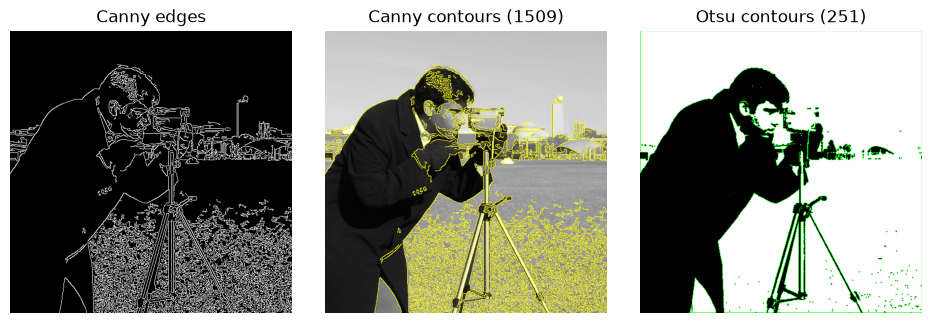

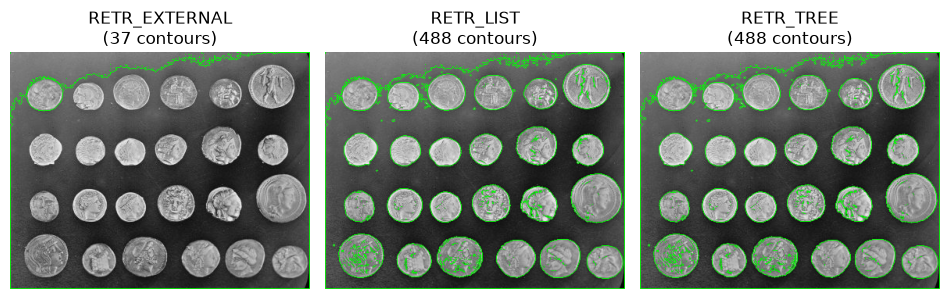

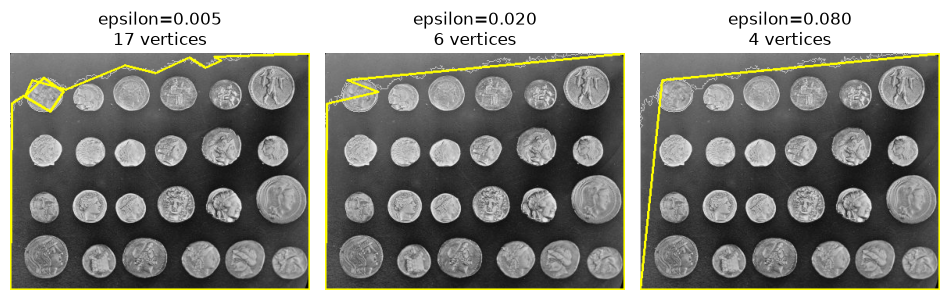

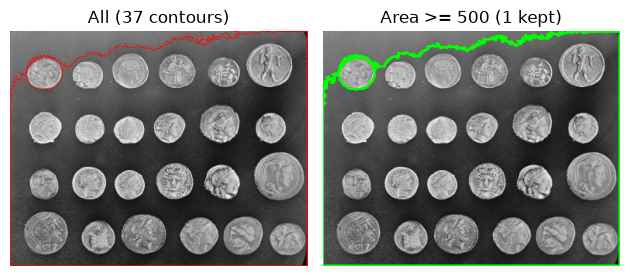

In [5]:
# --- B: contours from Canny vs Otsu threshold ---
canny_edges = cv2.Canny(camera, 50, 150)
cnt_canny, _ = cv2.findContours(canny_edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
vis_canny = cv2.cvtColor(camera, cv2.COLOR_GRAY2BGR)
cv2.drawContours(vis_canny, cnt_canny, -1, (0, 255, 255), 1)

vis_otsu = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)
cv2.drawContours(vis_otsu, contours, -1, (0, 255, 0), 1)

side_by_side(
    [canny_edges, vis_canny, vis_otsu],
    [f"Canny edges", f"Canny contours ({len(cnt_canny)})", f"Otsu contours ({len(contours)})"],
    rgb_flags=[False, True, True],
)

# --- C: RETR modes on coins (multiple objects) ---
coins = load_sample_image("coins")
_, coins_th = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
ret_imgs, ret_titles = [], []
for mode, name in [
    (cv2.RETR_EXTERNAL, "RETR_EXTERNAL"),
    (cv2.RETR_LIST, "RETR_LIST"),
    (cv2.RETR_TREE, "RETR_TREE"),
]:
    cnts, _ = cv2.findContours(coins_th, mode, cv2.CHAIN_APPROX_SIMPLE)
    vis = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(vis, cnts, -1, (0, 255, 0), 1)
    ret_imgs.append(vis)
    ret_titles.append(f"{name}\n({len(cnts)} contours)")
side_by_side(ret_imgs, ret_titles, rgb_flags=[True, True, True], cols=3)

# --- D: approxPolyDP — effect of epsilon ---
coin_cnts, _ = cv2.findContours(coins_th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
coin = max(coin_cnts, key=cv2.contourArea)
approx_imgs, approx_titles = [], []
for eps_frac in [0.005, 0.02, 0.08]:
    eps = eps_frac * cv2.arcLength(coin, True)
    poly = cv2.approxPolyDP(coin, eps, True)
    vis = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(vis, [coin], -1, (200, 200, 200), 1)
    cv2.drawContours(vis, [poly], -1, (0, 255, 255), 2)
    approx_imgs.append(vis)
    approx_titles.append(f"epsilon={eps_frac:.3f}\n{len(poly)} vertices")
side_by_side(approx_imgs, approx_titles, rgb_flags=[True, True, True], cols=3)

# --- E: filter contours by area ---
min_area = 500
filtered = []
for c in coin_cnts:
    if cv2.contourArea(c) >= min_area:
        filtered.append(c)
vis_filt = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
cv2.drawContours(vis_filt, coin_cnts, -1, (0, 0, 255), 1)
vis_keep = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
cv2.drawContours(vis_keep, filtered, -1, (0, 255, 0), 2)
side_by_side(
    [vis_filt, vis_keep],
    [f"All ({len(coin_cnts)} contours)", f"Area >= {min_area} ({len(filtered)} kept)"],
    rgb_flags=[True, True],
)

## 7. Summary

| Method | Output | Noise | Edge thickness | Best for |
|--------|--------|-------|----------------|----------|
| Sobel / Scharr | Gradient magnitude | Medium | Thick | Orientation, simple edges |
| Laplacian | 2nd derivative | High | Thin | Theory, zero-crossings |
| Canny | Binary edge map | Low (after blur) | Thin, connected | General edge detection |
| Contours | Vector curves | — | — | Shape analysis, measurement, counting objects |

| Contour tool | Use when |
|--------------|----------|
| `RETR_EXTERNAL` | Count separated objects, ignore holes |
| `RETR_TREE` | Need parent/child (object with holes) |
| `approxPolyDP` | Reduce vertices (triangles, rectangles) |
| Area filter | Drop small noise contours |
